## Data Exploration

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np

In [23]:
df = pd.read_csv(
   "../../data/raw/02_ground_truth_event_calendar.csv"
)
df.head()

,Date,Weekday,Event,Season x Month x Event Mult,DOW Mult,Month Mult,Event Mult,Discount Line Prob,Refund Txn Prob,Store Closed
0,2024-01-01,Monday,New Year's Day,0.401,0.90,0.8,0.50,0.3,0.0150,0
1,2024-01-02,Tuesday,January Returns Tail,0.682,0.85,0.8,0.85,0.3,0.0375,0
2,2024-01-03,Wednesday,January Returns Tail,0.683,0.90,0.8,0.85,0.3,0.0375,0
3,2024-01-04,Thursday,January Returns Tail,0.684,1.00,0.8,0.85,0.3,0.0375,0
4,2024-01-05,Friday,January Returns Tail,0.685,1.25,0.8,0.85,0.3,0.0375,0


In [24]:
df.shape

(731, 10)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         731 non-null    object 
 1   Weekday                      731 non-null    object 
 2   Event                        60 non-null     object 
 3   Season x Month x Event Mult  731 non-null    float64
 4   DOW Mult                     731 non-null    float64
 5   Month Mult                   731 non-null    float64
 6   Event Mult                   731 non-null    float64
 7   Discount Line Prob           731 non-null    float64
 8   Refund Txn Prob              731 non-null    float64
 9   Store Closed                 731 non-null    int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 57.2+ KB


In [26]:
df.dtypes

Date                            object
Weekday                         object
Event                           object
Season x Month x Event Mult    float64
DOW Mult                       float64
Month Mult                     float64
Event Mult                     float64
Discount Line Prob             float64
Refund Txn Prob                float64
Store Closed                     int64
dtype: object

In [27]:
df.duplicated().sum()

0

In [28]:
insights = pd.DataFrame({
    "missing_count": df.isna().sum(),
    'duplicated_count': df.duplicated().sum(),
    
    
})

insights

,missing_count,duplicated_count
Date,0,0
Weekday,0,0
Event,671,0
Season x Month x Event Mult,0,0
DOW Mult,0,0
Month Mult,0,0
Event Mult,0,0
Discount Line Prob,0,0
Refund Txn Prob,0,0
Store Closed,0,0


In [29]:
df.nunique()

Date                           731
Weekday                          7
Event                           21
Season x Month x Event Mult    257
DOW Mult                         6
Month Mult                      31
Event Mult                      16
Discount Line Prob               7
Refund Txn Prob                  3
Store Closed                     2
dtype: int64

In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Season x Month x Event Mult,731.0,1.059120,0.287001,0.000,0.948,1.042,1.074,3.5440
DOW Mult,731.0,1.113338,0.250404,0.850,0.900,1.000,1.350,1.5500
Month Mult,731.0,1.036772,0.152362,0.800,0.980,1.020,1.100,1.6000
Event Mult,731.0,1.018605,0.170121,0.000,1.000,1.000,1.000,2.8000
Discount Line Prob,731.0,0.314227,0.047210,0.300,0.300,0.300,0.300,0.6500
Refund Txn Prob,731.0,0.015923,0.005403,0.015,0.015,0.015,0.015,0.0525
Store Closed,731.0,0.002736,0.052271,0.000,0.000,0.000,0.000,1.0000


## Data Cleaning

In [31]:
df["Date"] = pd.to_datetime(df["Date"])

In [32]:
df['Event'].fillna('No Event', inplace=True)

C:\Users\ShehabYousef\AppData\Local\Temp\ipykernel_4836\568741280.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Event'].fillna('No Event', inplace=True)


## EDA

In [33]:
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns


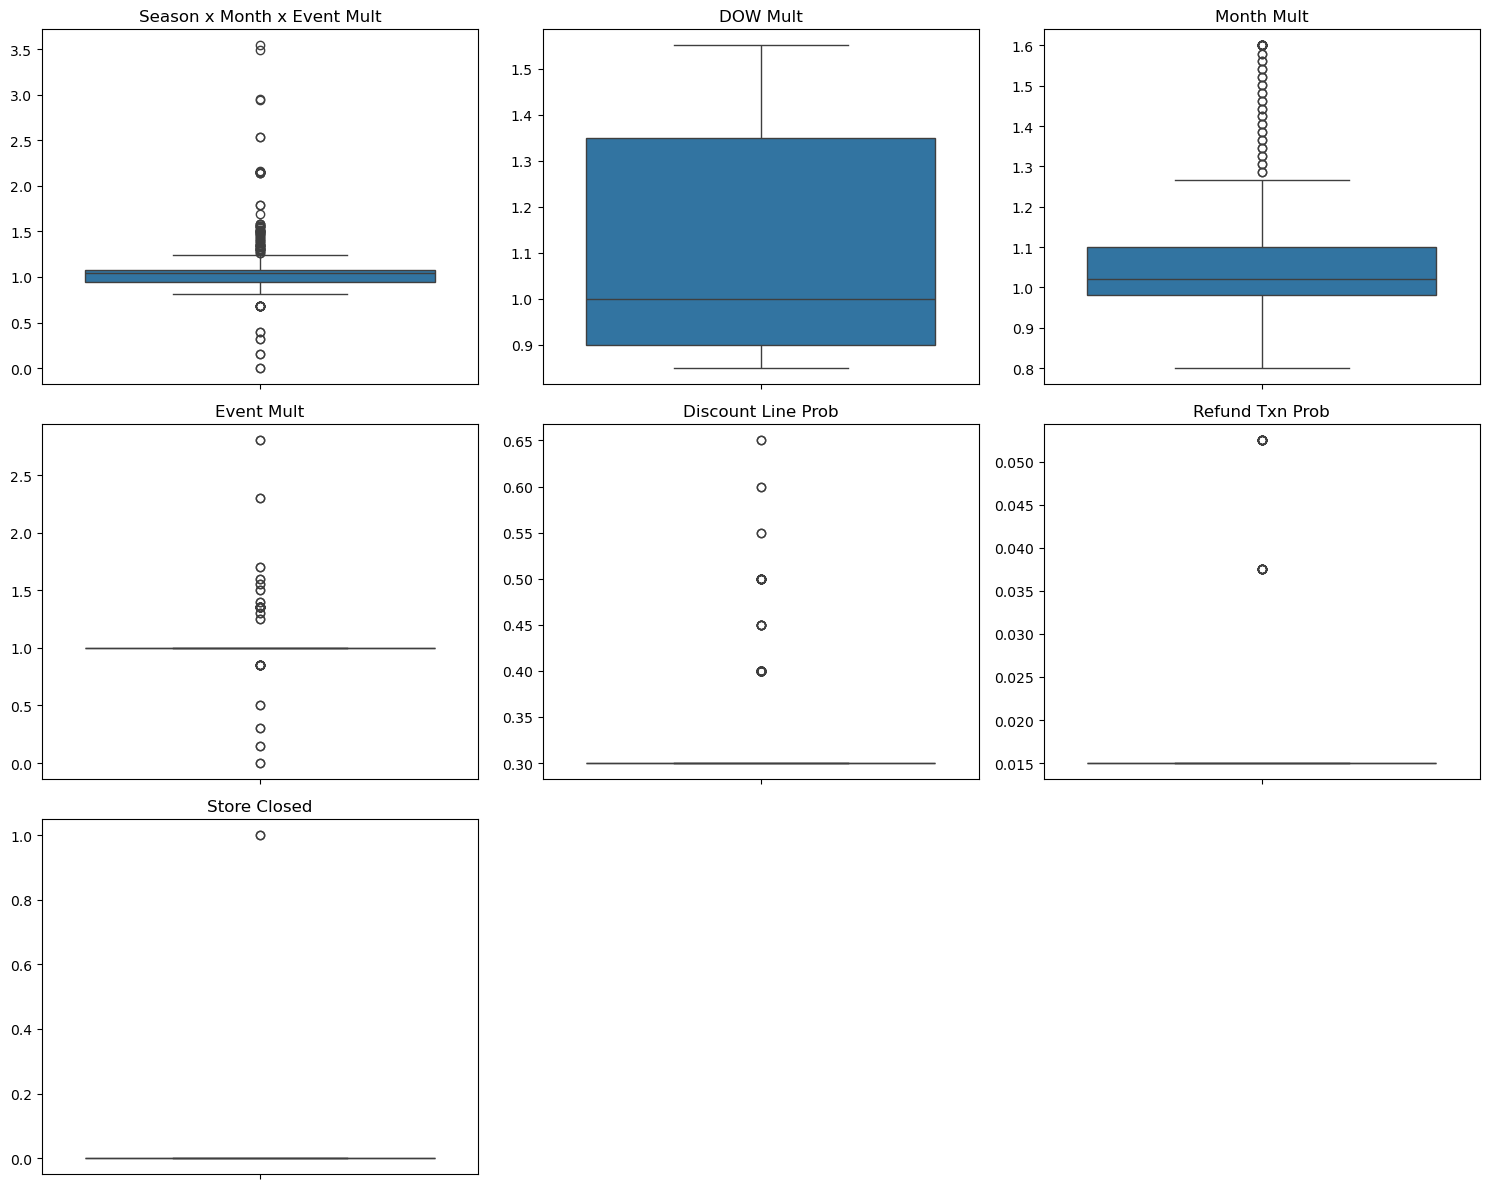

In [34]:
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

# إخفاء الـsubplots الفاضية
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

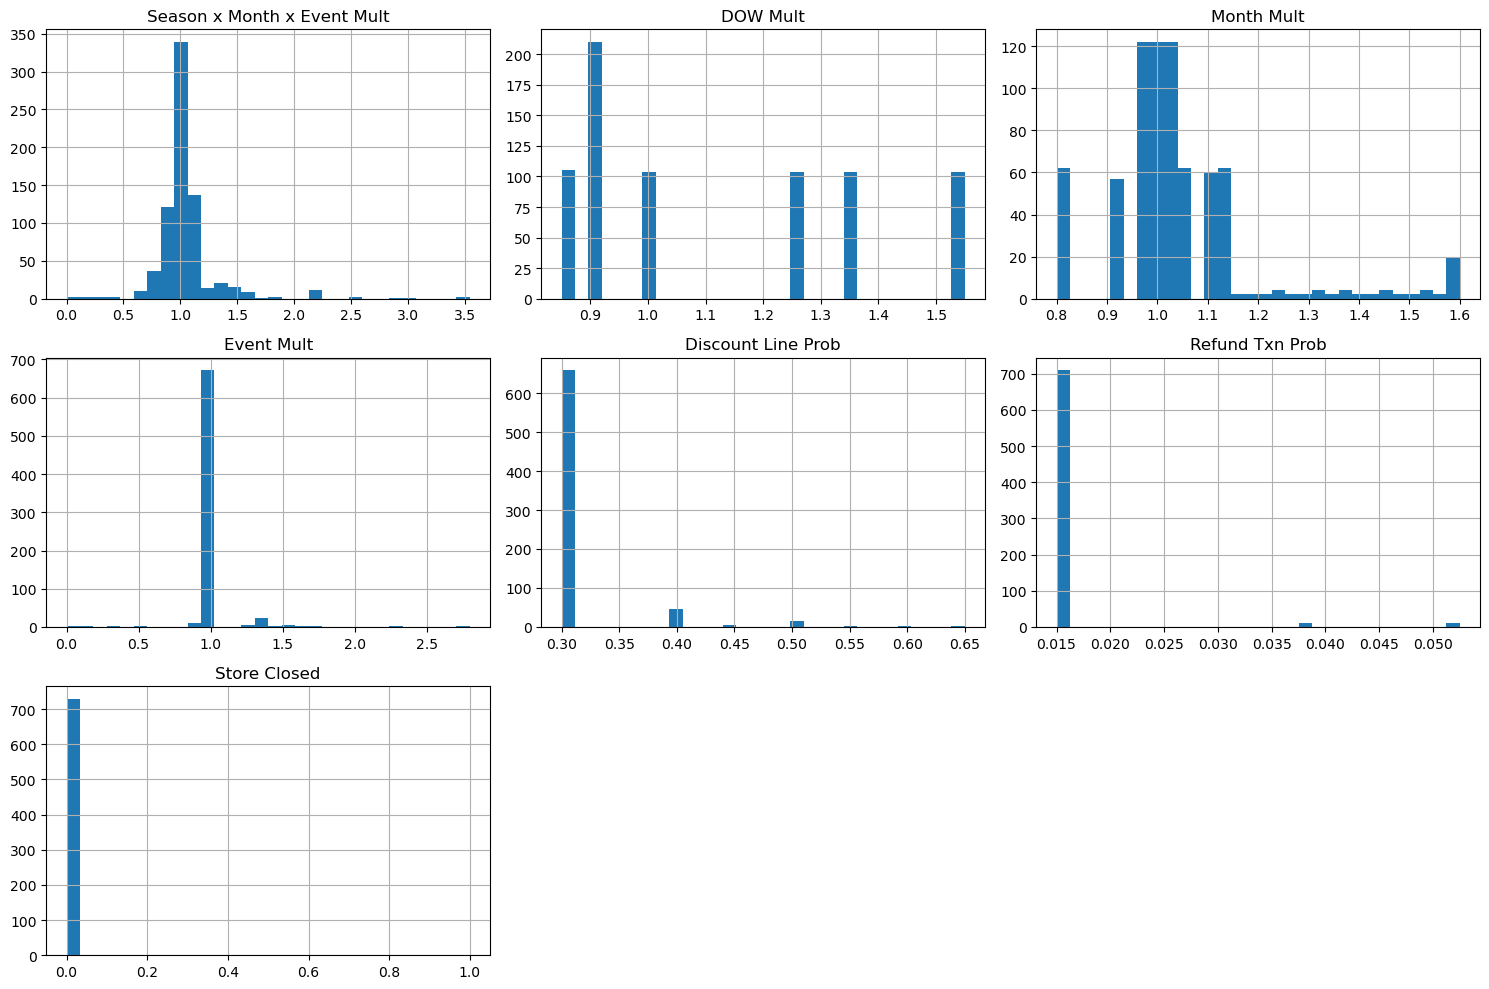

In [35]:
df[numeric_cols].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

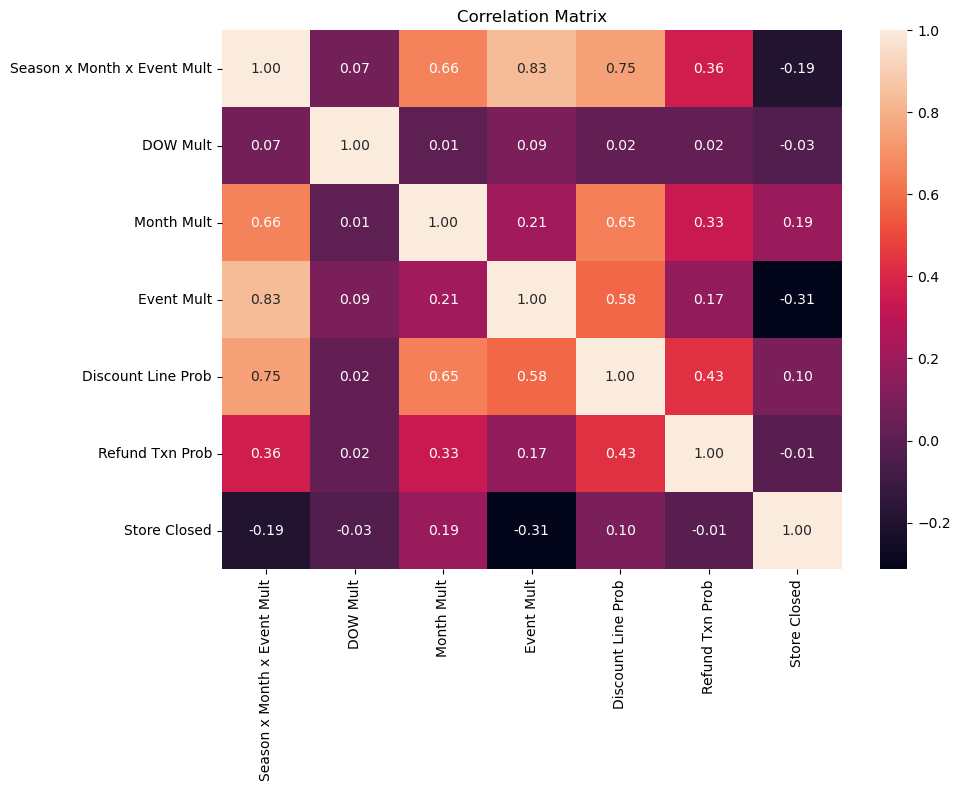

In [36]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Numerical EDA Findings

- Qty is highly concentrated around a single value.
- Unit Price shows a discrete/multi-modal distribution rather than a smooth continuous distribution.
- Several financial variables exhibit non-normal and multi-modal distributions.
- Discounts are heavily concentrated at zero with a negative tail.
- Negative observations are present in several financial variables.
- Gross Profit contains a substantial number of statistical outliers based on the IQR method.
- Unit Cost remains positive across the observed range.

In [37]:
df.to_csv("../../data/processed/02_ground_truth_event_calendar.csv", index=False)
